# Bitcoin Market Sentiment vs Trader Performance Analysis


## Objective
Analyze the relationship between Bitcoin market sentiment and trader profitability using:
- Fear & Greed Index dataset
- Hyperliquid historical trader data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fear_greed = pd.read_csv('fear_greed_index.csv')
historical = pd.read_csv('historical_data.csv')

# Clean column names
fear_greed.columns = fear_greed.columns.str.strip().str.lower()
historical.columns = historical.columns.str.strip()

# Check columns
print("Fear & Greed Columns:")
print(fear_greed.columns)

print("\nHistorical Data Columns:")
print(historical.columns)


Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Historical Data Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


## Data Cleaning

In [2]:
# Convert datetime columns
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

historical['Timestamp IST'] = pd.to_datetime(
    historical['Timestamp IST'],
    dayfirst=True
)

# Create common merge column
fear_greed['trade_date'] = fear_greed['date'].dt.date
historical['trade_date'] = historical['Timestamp IST'].dt.date

# Merge datasets
merged = historical.merge(
    fear_greed[['trade_date', 'classification']],
    on='trade_date',
    how='left'
)

merged.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


## Profitability Analysis by Sentiment

In [3]:
summary = merged.groupby('classification').agg(
    Trades=('Closed PnL', 'count'),
    Avg_PnL=('Closed PnL', 'mean'),
    Total_PnL=('Closed PnL', 'sum')
).reset_index()

print(summary)


  classification  Trades    Avg_PnL     Total_PnL
0   Extreme Fear   21400  34.537862  7.391102e+05
1  Extreme Greed   39992  67.892861  2.715171e+06
2           Fear   61837  54.290400  3.357155e+06
3          Greed   50303  42.743559  2.150129e+06
4        Neutral   37686  34.307718  1.292921e+06


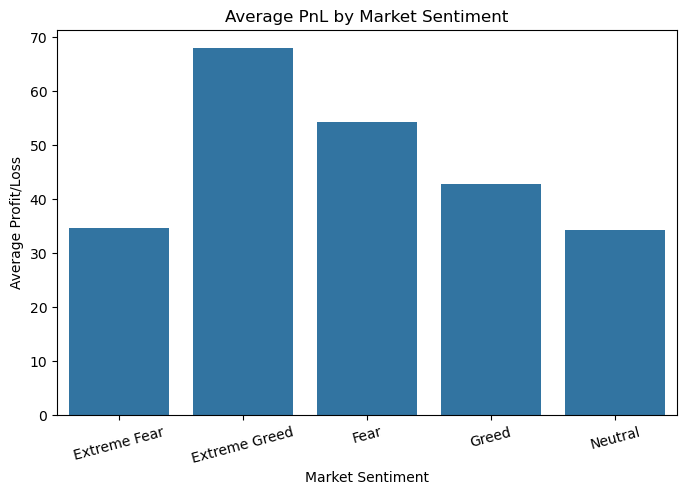

In [4]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x='classification',
    y='Avg_PnL'
)

plt.title('Average PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit/Loss')

plt.xticks(rotation=15)

plt.show()


## BUY vs SELL Performance

In [5]:
buy_sell = merged.groupby(
    ['classification', 'Side']
)['Closed PnL'].mean().reset_index()

print(buy_sell)


  classification  Side  Closed PnL
0   Extreme Fear   BUY   34.114627
1   Extreme Fear  SELL   34.980106
2  Extreme Greed   BUY   10.498927
3  Extreme Greed  SELL  114.584643
4           Fear   BUY   63.927104
5           Fear  SELL   45.049641
6          Greed   BUY   25.002302
7          Greed  SELL   59.691091
8        Neutral   BUY   29.227429
9        Neutral  SELL   39.456408


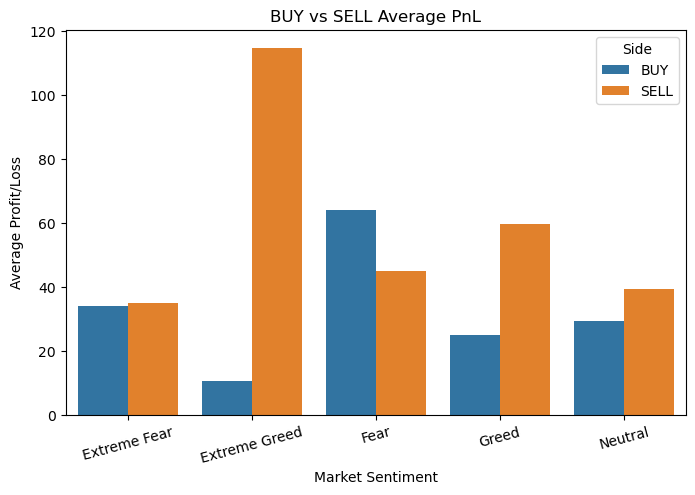

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=buy_sell,
    x='classification',
    y='Closed PnL',
    hue='Side'
)

plt.title('BUY vs SELL Average PnL')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit/Loss')

plt.xticks(rotation=15)

plt.show()



## Key Insights
- Extreme Greed periods showed the highest average profitability.
- Fear periods generated the highest total profits due to higher trading activity.
- SELL trades performed strongly during Greed conditions.
- BUY trades performed better during Fear markets.
- Market sentiment significantly influenced trader behavior and profitability.



## Conclusion
The analysis demonstrates a strong relationship between Bitcoin market sentiment and trader performance. Emotional market conditions created profitable opportunities, especially through contrarian trading strategies.
